## Introduction

The goal of this competition is to predict which passengers aboard the Titanic Spaceship were transported to an alternate dimension. 

This is a binary classification problem. My goal is to implement different supervised learning classification algorithms and select the model which has the highest accuracy for the test samples. Additionally, I will also check the precision, recall, and F1 score metric.

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import warnings

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Scikit-learn functions
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, auc, classification_report

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV

warnings.filterwarnings("ignore")

In [4]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [5]:
train = pd.read_csv('/kaggle/input/spaceship-titanic/train.csv')
test = pd.read_csv('/kaggle/input/spaceship-titanic/test.csv')

# Exploratory Data Analysis

First, I will explore each variable. I will use histogram to visualize the continuous variables and bar graph for categorical variables. I will also look at the correlation between the variables.


In [6]:
train.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [8]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RoomService'}>],
       [<Axes: title={'center': 'FoodCourt'}>,
        <Axes: title={'center': 'ShoppingMall'}>],
       [<Axes: title={'center': 'Spa'}>,
        <Axes: title={'center': 'VRDeck'}>]], dtype=object)

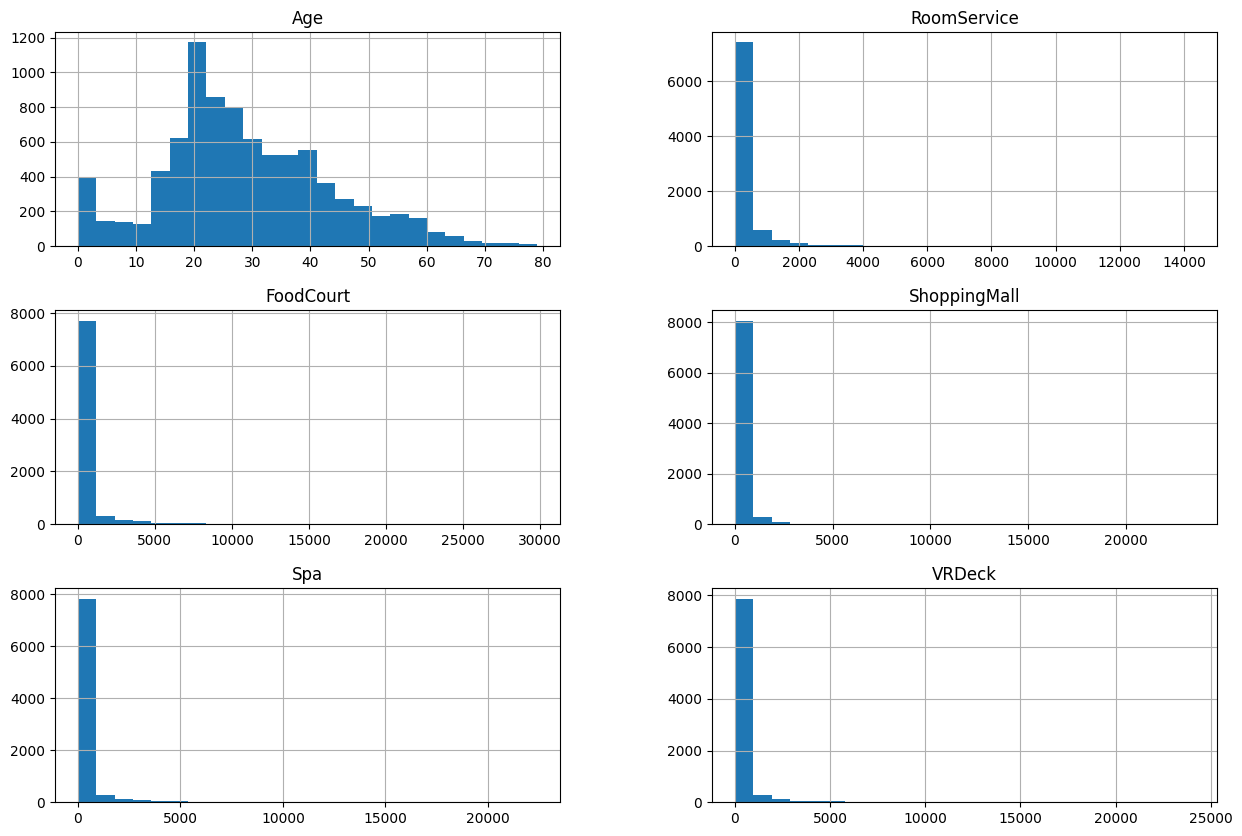

In [9]:
plt.rcParams['figure.figsize'] = (15, 10)
train[['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].hist(bins=25)

In [10]:
Numeric_list = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
Categorical_list = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

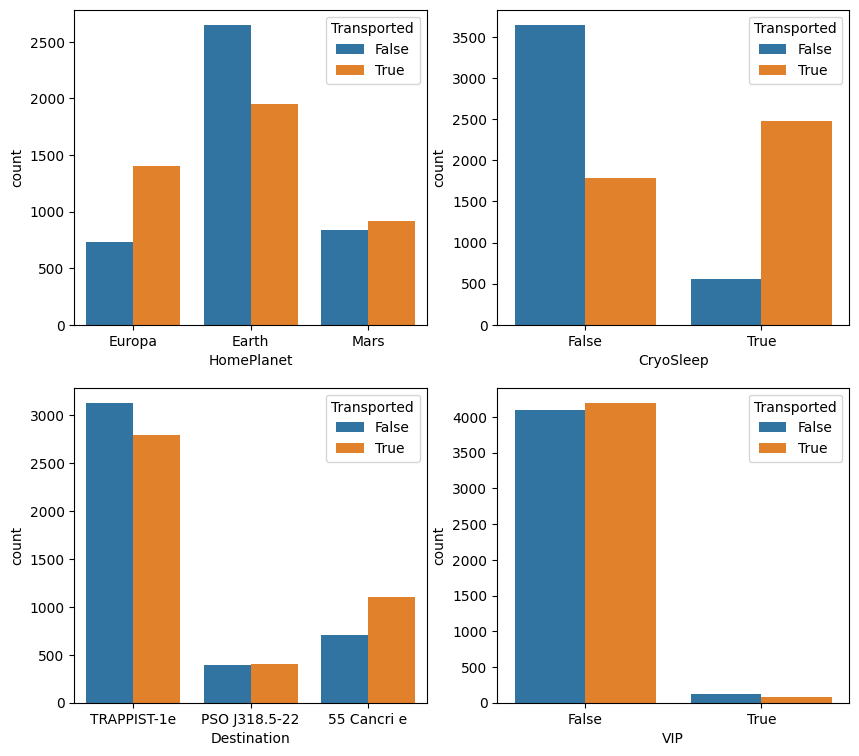

In [11]:
fig, axes = plt.subplots(2, 2, figsize = (10, 9))
axes = axes.ravel()

for i in range(len(Categorical_list)):
    ax = axes[i]
    col = Categorical_list[i]
    sns.countplot(x = col, data=train, hue='Transported', ax = ax)
plt.show()
    

<Axes: >

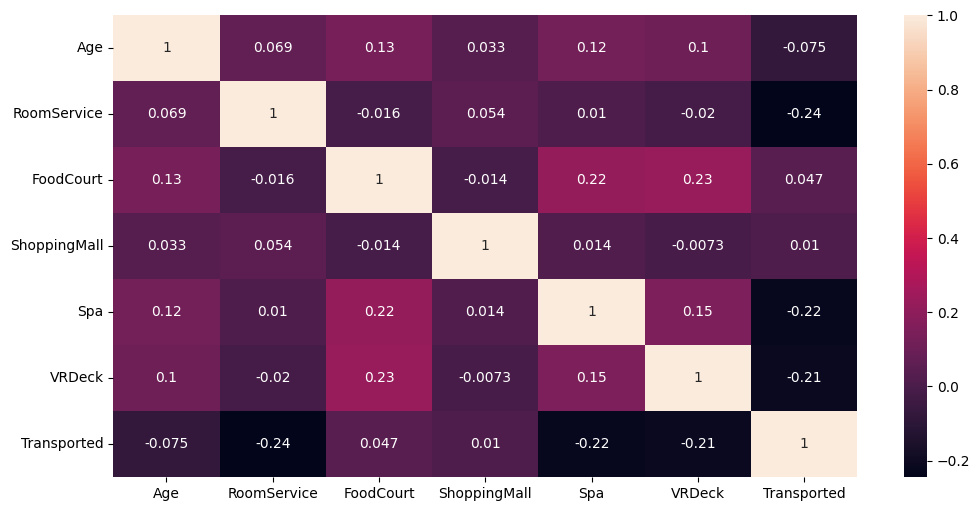

In [12]:
# Correlation between numeric variables
plt.rcParams['figure.figsize'] = (12, 6)
sns.heatmap(train.corr(method='pearson', numeric_only=True), annot=True)

# Data Preprocessing

## Missing value treatment

As seen above, all the variables except for `PassengerId` and `Transported` have missing values in them. There are multiple ways of handling the missing data. The easiest way is to drop the all the rows that have any missing value in them, but this leads to loss of data that can be used for training the model. The other approach is to impute the missing values by replacing them with the mean, median, most frequent values etc. or by imploying more sofisticated technique like K Nearest Neighbors approach. I will try each of them.

In [13]:
# Dropping missing values
print('# of rows after dropping missing data', format(train.dropna().shape[0]))

# of rows after dropping missing data 6606


In [14]:
# Missing value imputation using Simple replacement techniques
train_preprocess_v1 = train.copy()
#cat_list =  ['HomePlanet', 'Cabin', 'Destination', 'Europa', 'Earth', 'Mars',\
             #'TRAPPIST-1e', 'PSO J318.5-22', '55 Cancri e']

numeric_imputer = SimpleImputer(missing_values = np.nan, strategy='median')
categorical_imputer = SimpleImputer(missing_values = np.nan, strategy='most_frequent')

for col in Numeric_list:
    numeric_imputer.fit(train_preprocess_v1[[col]])
    train_preprocess_v1[col] = numeric_imputer.fit_transform(train_preprocess_v1[[col]])
    
for col2 in Categorical_list + ['Cabin']:
    train_preprocess_v1[col2] = categorical_imputer.fit_transform(train_preprocess_v1[col2].values.reshape(-1,1))[:,0]
    
print(train_preprocess_v1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8693 non-null   object 
 2   CryoSleep     8693 non-null   object 
 3   Cabin         8693 non-null   object 
 4   Destination   8693 non-null   object 
 5   Age           8693 non-null   float64
 6   VIP           8693 non-null   object 
 7   RoomService   8693 non-null   float64
 8   FoodCourt     8693 non-null   float64
 9   ShoppingMall  8693 non-null   float64
 10  Spa           8693 non-null   float64
 11  VRDeck        8693 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None


# Feature Engineering

In [15]:
# Passenger Group
train_preprocess_v1['Group'] = train_preprocess_v1['PassengerId'].apply(lambda x: x.split('_')[0])
train_preprocess_v1['GroupSize'] = train_preprocess_v1['PassengerId'].apply(lambda x: float(x.split('_')[1]))

# Cabin
train_preprocess_v1['CabinDeck'] = train_preprocess_v1['Cabin'].apply(lambda x: str(x).split('/')[0])
train_preprocess_v1['CabinNum'] = train_preprocess_v1['Cabin'].apply(lambda x: int(str(x).split('/')[1]))
train_preprocess_v1['CabinSide'] = train_preprocess_v1['Cabin'].apply(lambda x: str(x).split('/')[-1])

train_preprocess_v1.head(5)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Group,GroupSize,CabinDeck,CabinNum,CabinSide
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0001,1.0,B,0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0002,1.0,F,0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,0003,1.0,A,0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,0003,2.0,A,0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,0004,1.0,F,1,S


In [16]:
print('# of groups: ', format(train_preprocess_v1['Group'].unique()))
print('# of group sizes: ', format(train_preprocess_v1['GroupSize'].unique()))

print('# of cabin deck: ', format(train_preprocess_v1['CabinDeck'].unique()))
print('# of cabin num: ', format(train_preprocess_v1['CabinNum'].unique()))
print('# of cabin side: ', format(train_preprocess_v1['CabinSide'].unique()))

# of groups:  ['0001' '0002' '0003' ... '9278' '9279' '9280']
# of group sizes:  [1. 2. 3. 4. 5. 6. 7. 8.]
# of cabin deck:  ['B' 'F' 'A' 'G' 'E' 'D' 'C' 'T']
# of cabin num:  [   0    1    2 ... 1892 1893 1894]
# of cabin side:  ['P' 'S']


## Encoding Categorical values

In [17]:
onehot = OneHotEncoder()

for col in ['HomePlanet', 'Destination', 'CabinDeck', 'CabinSide']:
    onehot.fit(train_preprocess_v1[[col]])
    col_val_list = [col + '_' + x for x in train_preprocess_v1[col].unique().tolist()]
    one_hot_train = pd.DataFrame(onehot.transform(train_preprocess_v1[[col]]).toarray(), columns = col_val_list)
    train_preprocess_v1 = pd.concat([train_preprocess_v1, one_hot_train], axis=1)

train_preprocess_v1['CryoSleep'] = (train_preprocess_v1['CryoSleep'].fillna(value=False)).astype(int)
train_preprocess_v1['VIP'] = (train_preprocess_v1['VIP'].fillna(value=False)).astype(int)

In [18]:
X = train_preprocess_v1.drop(columns=['PassengerId', 'HomePlanet', 'Cabin', 'Destination', 
                                            'Name', 'Group', 'CabinDeck', 'CabinSide', 'Transported'])
Y = train_preprocess_v1[['Transported']]

train_X, val_X, train_Y, val_Y = train_test_split(X, Y, test_size = 0.2, random_state = 0)

### Preprocess Test Dataset

In [19]:
# Missing Value
test_preprocess = test.copy()
for col in Numeric_list:
    test_preprocess[col] = numeric_imputer.fit_transform(test_preprocess[[col]])
    
for col2 in Categorical_list + ['Cabin']:
    test_preprocess[col2] = categorical_imputer.fit_transform(test_preprocess[col2].values.reshape(-1,1))[:,0]
    
# Feature Engineering
test_preprocess['Group'] = test_preprocess['PassengerId'].apply(lambda x: x.split('_')[0])
test_preprocess['GroupSize'] = test_preprocess['PassengerId'].apply(lambda x: float(x.split('_')[1]))
test_preprocess['CabinDeck'] = test_preprocess['Cabin'].apply(lambda x: str(x).split('/')[0])
test_preprocess['CabinNum'] = test_preprocess['Cabin'].apply(lambda x: int(str(x).split('/')[1]))
test_preprocess['CabinSide'] = test_preprocess['Cabin'].apply(lambda x: str(x).split('/')[-1])

# Categorical Variable encoding
for col in ['HomePlanet', 'Destination', 'CabinDeck', 'CabinSide']:
    onehot.fit(test_preprocess[[col]])
    col_val_list = [col + '_' + x for x in test_preprocess[col].unique().tolist()]
    one_hot_train = pd.DataFrame(onehot.transform(test_preprocess[[col]]).toarray(), columns = col_val_list)
    test_preprocess = pd.concat([test_preprocess, one_hot_train], axis=1)

test_preprocess['CryoSleep'] = (test_preprocess['CryoSleep'].fillna(value=False)).astype(int)
test_preprocess['VIP'] = (test_preprocess['VIP'].fillna(value=False)).astype(int)

# Model training

### Logistic Regression

Logistic Regression is a supervised learning classification algorithm. It uses a logistic/sigmoid function to linear function of the independent variables. The model predicts a value between 0 and 1 which represents the probability of the passenger being transported. 

In [20]:
# Train a Logistic Regression model
logistic_clf = LogisticRegression(C=0.0001, solver='newton-cholesky', random_state=0)
logistic_clf.fit(train_X, train_Y)

# Predict using validation set
predicted_val_Y = logistic_clf.predict(val_X)
print('The mean accuracy for Logistic Regression is: ',format(logistic_clf.score(val_X, val_Y)))

The mean accuracy for Logistic Regression is:  0.7717078780908568


### KNeighbors Classifier

KNeighbors algorithm is a classification technique that implements the k-neighbors vote.

In [21]:
# Train a K Nearest Neighbors model
knn_clf = KNeighborsClassifier(n_neighbors = 9)
knn_clf.fit(train_X, train_Y)

# Predict using validation set
predicted_val_Y = knn_clf.predict(val_X)
print('The mean accuracy for KNN is: ',format(knn_clf.score(val_X, val_Y)))

The mean accuracy for KNN is:  0.772857964347326


### Decision Tree Classifier

In [22]:
dt_clf = tree.DecisionTreeClassifier()
dt_clf.fit(train_X, train_Y)

# Predict using validation set
predicted_val_Y = dt_clf.predict(val_X)
print('The mean accuracy for Decision Tree Classifier is: ',format(dt_clf.score(val_X, val_Y)))

The mean accuracy for Decision Tree Classifier is:  0.7412305922944221


### Supervised Vector Machines

In [23]:
lin_svc_clf = SVC(kernel="linear", C=0.025, random_state=0)
lin_svc_clf.fit(train_X, train_Y)

# Predict using validation set
predicted_val_Y = lin_svc_clf.predict(val_X)
print('The mean accuracy for Linear SVM Classifier is: ',format(lin_svc_clf.score(val_X, val_Y)))

The mean accuracy for Linear SVM Classifier is:  0.7964347326049454


## Ensemble Techniques

### Gradient Boosted Trees

In [24]:
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.5, random_state=0)
gb_clf.fit(train_X, train_Y)

# Prediction on validation set
predicted_val_Y = gb_clf.predict(val_X)
print('The mean accuracy for Gradient Boosted Classifier is: ',format(gb_clf.score(val_X, val_Y)))

# Get feature importance scores
print('\nFeature Importance score for Gradient Boosted Trees are:\n')
for x, y in zip(gb_clf.feature_names_in_, gb_clf.feature_importances_):
                print(x + '\t\t ' + str(y))

The mean accuracy for Gradient Boosted Classifier is:  0.8050603795284647

Feature Importance score for Gradient Boosted Trees are:

CryoSleep		 0.32614407332008666
Age		 0.029842791790367012
VIP		 0.000416219114291454
RoomService		 0.08556333281414621
FoodCourt		 0.0802246760227004
ShoppingMall		 0.044329631354080676
Spa		 0.11637037638296563
VRDeck		 0.10108861233190998
GroupSize		 0.0033179107306343216
CabinNum		 0.0750395911068438
HomePlanet_Europa		 0.044833844624877335
HomePlanet_Earth		 0.01567976104913746
HomePlanet_Mars		 0.008700585361624465
Destination_TRAPPIST-1e		 0.0025800413409620333
Destination_PSO J318.5-22		 0.0013065544471515024
Destination_55 Cancri e		 0.0029416615474309247
CabinDeck_B		 0.000687342069494005
CabinDeck_F		 0.00047255783715333826
CabinDeck_A		 0.004243528908218243
CabinDeck_G		 0.000610830713194641
CabinDeck_E		 0.019005804616710524
CabinDeck_D		 0.0022267323333049135
CabinDeck_C		 0.017414683033313977
CabinDeck_T		 0.0
CabinSide_P		 0.01365999562827

### Random Forest Classifier

In [25]:
rf_clf = RandomForestClassifier(n_estimators=50, random_state=0)
rf_clf.fit(train_X, train_Y)

# Prediction on validation set
predicted_val_Y = rf_clf.predict(val_X)
print('The mean accuracy for Random Forest Classifier is: ',format(rf_clf.score(val_X, val_Y)))

# Get feature importance scores
print('\nFeature Importance score for Random Forest Classifier are:\n')
for x, y in zip(rf_clf.feature_names_in_, rf_clf.feature_importances_):
                print(x + '\t\t ' + str(y))
        
rf_clf.get_params()

The mean accuracy for Random Forest Classifier is:  0.8062104657849338

Feature Importance score for Random Forest Classifier are:

CryoSleep		 0.08803399891641016
Age		 0.12442573975892224
VIP		 0.001992381062816719
RoomService		 0.09512091344874943
FoodCourt		 0.08038832960629475
ShoppingMall		 0.07385972062727392
Spa		 0.10559206274449975
VRDeck		 0.09246185422136186
GroupSize		 0.030402216691158532
CabinNum		 0.16388116797805108
HomePlanet_Europa		 0.018672901294094484
HomePlanet_Earth		 0.01764446119024895
HomePlanet_Mars		 0.008173078832072604
Destination_TRAPPIST-1e		 0.008109358934483408
Destination_PSO J318.5-22		 0.005556958343924493
Destination_55 Cancri e		 0.010288948538474936
CabinDeck_B		 0.0019428548950298464
CabinDeck_F		 0.0056510945366062305
CabinDeck_A		 0.005664809375893495
CabinDeck_G		 0.0035267064137495864
CabinDeck_E		 0.010999856926652231
CabinDeck_D		 0.014578252083920853
CabinDeck_C		 0.011491020184004379
CabinDeck_T		 4.627214399578947e-05
CabinSide_P		 0.0

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 50,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 0,
 'verbose': 0,
 'warm_start': False}

### Extra Tree Classifier

In [26]:
xtree_clf = ExtraTreesClassifier(n_estimators=100, random_state=0)
xtree_clf.fit(train_X, train_Y)

# Prediction on validation set
predicted_val_Y = xtree_clf.predict(val_X)
print('The mean accuracy for Extra Tree Classifier is: ',format(xtree_clf.score(val_X, val_Y)))

# Get feature importance scores
print('\nFeature Importance score for Extra Tree Classifier are:\n')
for x, y in zip(xtree_clf.feature_names_in_, xtree_clf.feature_importances_):
                print(x + '\t\t ' + str(y))

The mean accuracy for Extra Tree Classifier is:  0.8004600345025877

Feature Importance score for Extra Tree Classifier are:

CryoSleep		 0.16495610853316972
Age		 0.13509971400468127
VIP		 0.004066782556669723
RoomService		 0.07120935255077847
FoodCourt		 0.06522022554179745
ShoppingMall		 0.06429348308090853
Spa		 0.08384234184476212
VRDeck		 0.07705829590073195
GroupSize		 0.04178159312444978
CabinNum		 0.16093676205410656
HomePlanet_Europa		 0.015110031345724594
HomePlanet_Earth		 0.014097107718285208
HomePlanet_Mars		 0.009977287792763533
Destination_TRAPPIST-1e		 0.007487926742827839
Destination_PSO J318.5-22		 0.004782785397862685
Destination_55 Cancri e		 0.008940453956708545
CabinDeck_B		 0.0019754849459159784
CabinDeck_F		 0.008558264778085028
CabinDeck_A		 0.0055557783077899376
CabinDeck_G		 0.0037629596021836096
CabinDeck_E		 0.009838888292629137
CabinDeck_D		 0.013673410745587264
CabinDeck_C		 0.011069448067162892
CabinDeck_T		 0.00015440162351476483
CabinSide_P		 0.008377

### Grid Search Emsemble model

From the above steps, I see that ensemble model techniques give 80% score on the validation step. Next, I pick RandomForestClassifier and try to tune the hyperparameters by grid search method to see if I can further improve accuracy.

In [27]:
param_grid = {"n_estimators": [10, 50, 100],
              "oob_score": [True, False],
              "warm_start": [True, False]
             }
estimator = RandomForestClassifier(random_state=0)
clf = GridSearchCV(estimator, param_grid)
clf.fit(train_X, train_Y)

print('The mean accuracy for Grid Search is: ',format(clf.score(val_X, val_Y)))

The mean accuracy for Grid Search is:  0.80448533640023


In [28]:
print(clf.best_params_)

{'n_estimators': 100, 'oob_score': True, 'warm_start': True}


In [29]:
# Retrain RF Classifier with better params
rf_clf = RandomForestClassifier(n_estimators=50, random_state=0, oob_score=True, warm_start=True)
rf_clf.fit(train_X, train_Y)

print('The mean accuracy for Random Forest Classifier is: ',format(rf_clf.score(val_X, val_Y)))

# Get feature importance scores
print('\nFeature Importance score for Random Forest Classifier are:\n')
for x, y in zip(rf_clf.feature_names_in_, rf_clf.feature_importances_):
                print(x + '\t\t ' + str(y))
        

The mean accuracy for Random Forest Classifier is:  0.8062104657849338

Feature Importance score for Random Forest Classifier are:

CryoSleep		 0.08803399891641016
Age		 0.12442573975892224
VIP		 0.001992381062816719
RoomService		 0.09512091344874943
FoodCourt		 0.08038832960629475
ShoppingMall		 0.07385972062727392
Spa		 0.10559206274449975
VRDeck		 0.09246185422136186
GroupSize		 0.030402216691158532
CabinNum		 0.16388116797805108
HomePlanet_Europa		 0.018672901294094484
HomePlanet_Earth		 0.01764446119024895
HomePlanet_Mars		 0.008173078832072604
Destination_TRAPPIST-1e		 0.008109358934483408
Destination_PSO J318.5-22		 0.005556958343924493
Destination_55 Cancri e		 0.010288948538474936
CabinDeck_B		 0.0019428548950298464
CabinDeck_F		 0.0056510945366062305
CabinDeck_A		 0.005664809375893495
CabinDeck_G		 0.0035267064137495864
CabinDeck_E		 0.010999856926652231
CabinDeck_D		 0.014578252083920853
CabinDeck_C		 0.011491020184004379
CabinDeck_T		 4.627214399578947e-05
CabinSide_P		 0.0

# Submission

In [30]:
# Get Predicted Target for test data
test_X = test_preprocess[list(train_X.columns)]
Pred_Y = rf_clf.predict(test_X)

# Prepare for submission
sample_submission_df = pd.read_csv('/kaggle/input/spaceship-titanic/sample_submission.csv')
print(sample_submission_df.head(5))

submission_df = pd.DataFrame(list(zip(test['PassengerId'], Pred_Y)), columns=list(sample_submission_df.columns))

submission_df.to_csv('/kaggle/working/submission.csv', index=False)

  PassengerId  Transported
0     0013_01        False
1     0018_01        False
2     0019_01        False
3     0021_01        False
4     0023_01        False
